# Notebook 03 — Prototipo SAM3 con detectores externos + texto directo

Este notebook prueba **SAM3** sobre el mismo frame preprocesado del notebook 01. La diferencia con el [notebook 02](02_sam2_prototipo.ipynb) (que usa SAM2) son **dos cosas**:

1. SAM3 segmenta con un encoder más nuevo y multi-instancia.
2. SAM3 **acepta prompts de texto directamente** — es decir, internaliza un detector y no necesita Grounding DINO adelante.

## Pipeline de los 3 enfoques

```
Enfoque A:  frame  →  blob_log         →  puntos  →  SAM3  →  máscaras
Enfoque B:  frame  →  Grounding DINO   →  cajas   →  SAM3  →  máscaras
Enfoque C:  frame  →                       SAM3 (con texto directo)  →  máscaras
                                       (detector + segmentador en uno)
```

Los enfoques A y B son **idénticos al notebook 02**, sólo cambia el segmentador (SAM2 → SAM3). El **C es exclusivo de SAM3** y es donde vamos a ver el verdadero salto.

## ¿Qué cambió SAM3 vs SAM2?

| Aspecto                                     | SAM2 (2024) | SAM3 (2025)   |
| ------------------------------------------- | ----------- | ------------- |
| Prompts visuales (puntos, cajas, máscaras)  | ✅          | ✅            |
| Prompts de texto abierto                    | ❌          | ✅            |
| Detección + segmentación en una sola pasada | ❌          | ✅            |
| Tracking en video                           | ✅          | ✅ (mejorado) |

## Importante: SAM3 es gated

Hay que tener acceso aprobado en https://huggingface.co/facebook/sam3 y haberse autenticado en la máquina con `uv run huggingface-cli login`. Si la celda de carga falla con `OSError`, es probable que el acceso no esté aprobado todavía.


---

## Setup

Mismo arranque que el notebook 02: cargamos un frame, lo pasamos por el pipeline de preprocesamiento.


In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

sys.path.append(str(Path("..") / "src"))
from axonal_tracking.ets_reader import encontrar_ets, leer_header_ets, leer_frame
from axonal_tracking import preprocesamiento as pp
from axonal_tracking import visualizacion as viz
from axonal_tracking import configuracion as cfg

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print(f"Device: {device}")

# Configuracion compartida (escrita por el notebook 01).
config = cfg.cargar_configuracion()
VIDEO = config["video"]["ruta"]
ROI = config["video"]["roi"]
FRAME_IDX = config["frames"]["demo"]
MODO = config["procesamiento"]["modo"]
print(f"Config: video={VIDEO.name}, frame={FRAME_IDX}, modo={MODO}")

ets = encontrar_ets(VIDEO)
info = leer_header_ets(ets)
frame_u16 = leer_frame(info, FRAME_IDX)

# Pipeline de preprocesamiento segun el modo configurado.
fondo_temporal = None
if MODO != "rgb_crudo":
    n_contexto = config["procesamiento"]["parametros"].get("n_frames_temporal", 10)
    subvideo = np.stack([leer_frame(info, i) for i in range(n_contexto)])
    fondo_temporal = pp.calcular_fondo_temporal(subvideo, metodo="mediana")
    print(f"Contexto temporal: {n_contexto} frames, fondo shape={fondo_temporal.shape}")

pasos = cfg.aplicar_modo_frame(frame_u16, config, fondo_temporal=fondo_temporal)
frame_rgb = pasos["rgb_uint8"]
frame_pil = Image.fromarray(frame_rgb)
frame_limpio = pasos["sin_ruido"]

print(f"Frame listo: shape={frame_rgb.shape}, dtype={frame_rgb.dtype}")

Device: mps
Config: video=Movie_266.vsi, frame=0, modo=configurable
Contexto temporal: 111 frames, fondo shape=(2048, 2048)
Frame listo: shape=(81, 2083, 3), dtype=uint8


---

## Carga del modelo SAM3

La primera carga descarga varios GB. Tarda unos minutos.


In [2]:
from transformers import Sam3Processor, Sam3Model

MODEL_ID = "facebook/sam3"
print(f"Cargando {MODEL_ID}...")
processor_sam3 = Sam3Processor.from_pretrained(MODEL_ID)
model_sam3 = Sam3Model.from_pretrained(MODEL_ID).to(device).eval()
n_params = sum(p.numel() for p in model_sam3.parameters()) / 1e6
print(f"OK — SAM3 cargado en {device} ({n_params:.0f} M parametros)")

Cargando facebook/sam3...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

OK — SAM3 cargado en mps (840 M parametros)


---

## Enfoque A — blob_log + SAM3 (cajas a partir de blobs)

Igual que en el notebook 02 a nivel conceptual: detector clásico LoG → SAM3 segmenta lo que está en cada candidato. **Diferencia técnica importante:** SAM3 **no acepta `input_points`** como prompts, sólo `input_boxes`. Es un cambio de API respecto a SAM2.

Solución: para cada blob `(y, x, σ)` que devuelve `blob_log`, construimos una caja chiquita centrada en `(x, y)` con radio `≈ σ·√2 + padding`. Eso convierte cada blob en una bounding box que SAM3 sí acepta. El resultado conceptualmente es lo mismo — segmentar el objeto que está alrededor de la posición detectada.


In [3]:
from skimage.feature import blob_log

f_norm = frame_limpio / frame_limpio.max() if frame_limpio.max() > 0 else frame_limpio
blobs = blob_log(f_norm, min_sigma=1, max_sigma=3, num_sigma=5, threshold=0.05)

N_MAX = 30
intensidades = np.array([frame_limpio[int(y), int(x)] for y, x, _ in blobs])
orden = np.argsort(intensidades)[::-1][:N_MAX]
blobs_top = blobs[orden]
print(
    f"blob_log: {len(blobs)} blobs totales, pasamos los {len(blobs_top)} mas intensos a SAM3."
)

# A diferencia de SAM2, SAM3 NO acepta input_points: solo input_boxes.
# Convertimos cada blob en una caja chiquita centrada en (x,y) con radio = sigma + padding.
H, W = frame_rgb.shape[:2]


def blob_a_caja(y, x, sigma, padding=2):
    r = max(sigma * np.sqrt(2) + padding, 3.0)
    return [
        max(float(x - r), 0.0),
        max(float(y - r), 0.0),
        min(float(x + r), float(W - 1)),
        min(float(y + r), float(H - 1)),
    ]


cajas_blobs = [blob_a_caja(y, x, s) for y, x, s in blobs_top]
input_boxes_a = [cajas_blobs]  # 3 niveles: [imagen, objeto, [x1,y1,x2,y2]]

inputs_a = processor_sam3(
    images=frame_pil,
    input_boxes=input_boxes_a,
    return_tensors="pt",
).to(device)

with torch.no_grad():
    outputs_a = model_sam3(**inputs_a)

# SAM3 no tiene post_process_masks; todo va por post_process_instance_segmentation.
resultados_a = processor_sam3.post_process_instance_segmentation(
    outputs_a,
    threshold=0.5,  # filtramos hipotesis debiles (SAM3 devuelve muchas por caja)
    target_sizes=[(frame_pil.size[1], frame_pil.size[0])],
)[0]

m_arr_a = resultados_a.get("masks", None)
if m_arr_a is not None and hasattr(m_arr_a, "cpu"):
    m_arr_a = m_arr_a.cpu().numpy()
elif m_arr_a is None:
    m_arr_a = np.zeros((0, *frame_rgb.shape[:2]), dtype=bool)

print(f"SAM3 devolvio {len(m_arr_a)} mascaras.")

blob_log: 8 blobs totales, pasamos los 8 mas intensos a SAM3.
SAM3 devolvio 5 mascaras.


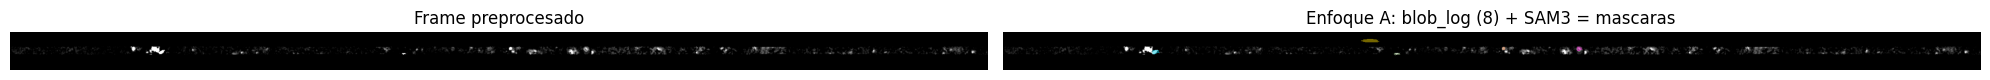

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 9))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=ax0)
viz.overlay_mascaras(frame_rgb, m_arr_a, ax=ax1)
ax1.set_title(f"Enfoque A: blob_log ({len(blobs_top)}) + SAM3 = mascaras")
plt.tight_layout()
plt.show()

---

## Enfoque B — Grounding DINO + SAM3

El "Grounded SAM" clásico, pero con SAM3 como segmentador. Sirve de **referencia** contra el Enfoque C: vamos a ver si SAM3 con texto directo le gana a este pipeline en dos pasos.


In [5]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DINO_ID = "IDEA-Research/grounding-dino-tiny"
print(f"Cargando {DINO_ID}...")
processor_dino = AutoProcessor.from_pretrained(DINO_ID)
model_dino = (
    AutoModelForZeroShotObjectDetection.from_pretrained(DINO_ID).to(device).eval()
)
print("OK")

Cargando IDEA-Research/grounding-dino-tiny...


Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

OK


In [6]:
TEXTO_DINO = "small fluorescent particle."

# Le pasamos a GDINO el frame ANTES del enmascarado del ROI, asi tiene mas
# estructura visual para identificar objetos. Despues filtramos las cajas que
# caigan fuera del ROI.
frame_rgb_completo = pp.frame_a_rgb_uint8(pasos["sin_ruido"])
frame_pil_completo = Image.fromarray(frame_rgb_completo)

inputs_dino = processor_dino(
    images=frame_pil_completo, text=TEXTO_DINO, return_tensors="pt"
).to(device)
with torch.no_grad():
    outputs_dino = model_dino(**inputs_dino)

resultados_dino = processor_dino.post_process_grounded_object_detection(
    outputs_dino,
    inputs_dino.input_ids,
    threshold=0.35,
    text_threshold=0.20,
    target_sizes=[(frame_pil.size[1], frame_pil.size[0])],
)[0]
boxes_dino = resultados_dino["boxes"].cpu().numpy()
scores_dino = resultados_dino["scores"].cpu().numpy()
print(f'Grounding DINO con "{TEXTO_DINO}": {len(boxes_dino)} cajas totales.')

# Filtro 1 — Descartar cajas gigantes (probables falsos positivos tipo
# "todo el axon es un objeto unico").
H, W = frame_rgb.shape[:2]
area_frame = H * W
MAX_AREA_FRAC = 0.05  # ninguna caja puede cubrir mas del 5% del frame
areas = np.array([(b[2] - b[0]) * (b[3] - b[1]) / area_frame for b in boxes_dino])
mask_chicas = areas < MAX_AREA_FRAC

# Filtro 2 — Si hay mascara de ROI, descartar cajas que caen fuera del axon.
if pasos["mascara_roi"] is not None:
    mascara = pasos["mascara_roi"]
    MIN_OVERLAP_ROI = 0.3

    def caja_en_roi(box):
        x1, y1, x2, y2 = [int(v) for v in box]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        if x2 <= x1 or y2 <= y1:
            return False
        recorte = mascara[y1:y2, x1:x2]
        return recorte.sum() / recorte.size > MIN_OVERLAP_ROI

    mask_roi = (
        np.array([caja_en_roi(b) for b in boxes_dino])
        if len(boxes_dino)
        else np.array([], dtype=bool)
    )
else:
    mask_roi = np.ones(len(boxes_dino), dtype=bool)

mask_total = mask_chicas & mask_roi
boxes_dino_f = boxes_dino[mask_total]
scores_dino_f = scores_dino[mask_total]
print(
    f"Tras filtros (area <{MAX_AREA_FRAC*100:.0f}% + dentro de ROI): {len(boxes_dino_f)} cajas."
)

if len(boxes_dino_f) > 0:
    input_boxes_b = [boxes_dino_f.tolist()]
    inputs_b = processor_sam3(
        images=frame_pil,
        input_boxes=input_boxes_b,
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        outputs_b = model_sam3(**inputs_b)

    resultados_b = processor_sam3.post_process_instance_segmentation(
        outputs_b,
        threshold=0.5,
        target_sizes=[(frame_pil.size[1], frame_pil.size[0])],
    )[0]
    m_arr_b = resultados_b.get("masks", None)
    if m_arr_b is not None and hasattr(m_arr_b, "cpu"):
        m_arr_b = m_arr_b.cpu().numpy()
    elif m_arr_b is None:
        m_arr_b = np.zeros((0, *frame_rgb.shape[:2]), dtype=bool)
else:
    m_arr_b = np.zeros((0, *frame_rgb.shape[:2]), dtype=bool)

print(f"SAM3 sobre cajas filtradas: {len(m_arr_b)} mascaras.")

Grounding DINO con "small fluorescent particle.": 1 cajas totales.
Tras filtros (area <5% + dentro de ROI): 0 cajas.
SAM3 sobre cajas filtradas: 0 mascaras.


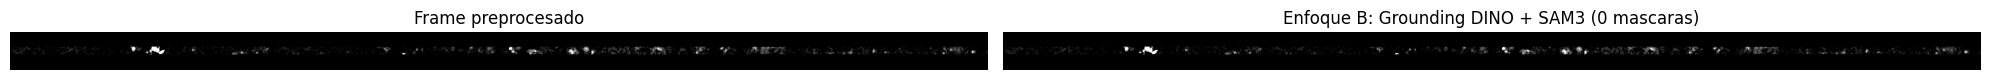

In [7]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 9))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=ax0)
viz.overlay_mascaras(frame_rgb, m_arr_b, ax=ax1)
ax1.set_title(f"Enfoque B: Grounding DINO + SAM3 ({len(m_arr_b)} mascaras)")
plt.tight_layout()
plt.show()

---

## Enfoque C — SAM3 con texto directo (la novedad)

Acá está la **diferencia fundamental con SAM2**. Le pasamos al modelo la imagen + texto, y devuelve directamente una lista de instancias con sus máscaras y scores. **Sin detector externo.**

Vamos a probar 3 frases ("queries") para ver cuál responde mejor:


In [8]:
TEXT_QUERIES = [
    "small white bright dot",
    "fluorescent particle",
    "vesicle",
]
SCORE_THRESHOLD = 0.3


def detectar_con_texto(image_pil, text):
    """SAM3 con prompt de texto -> mascaras + scores de cada instancia."""
    inputs = processor_sam3(images=image_pil, text=text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_sam3(**inputs)
    target_size = [(image_pil.size[1], image_pil.size[0])]
    resultados = processor_sam3.post_process_instance_segmentation(
        outputs,
        threshold=SCORE_THRESHOLD,
        target_sizes=target_size,
    )[0]
    return resultados.get("masks", None), resultados.get("scores", None)


detecciones_c = {}
for q in TEXT_QUERIES:
    masks, scores = detectar_con_texto(frame_pil, q)
    n = 0 if masks is None else len(masks)
    detecciones_c[q] = (masks, scores)
    print(f'  "{q}" -> {n} instancias (score >= {SCORE_THRESHOLD})')

  "small white bright dot" -> 12 instancias (score >= 0.3)
  "fluorescent particle" -> 11 instancias (score >= 0.3)
  "vesicle" -> 0 instancias (score >= 0.3)


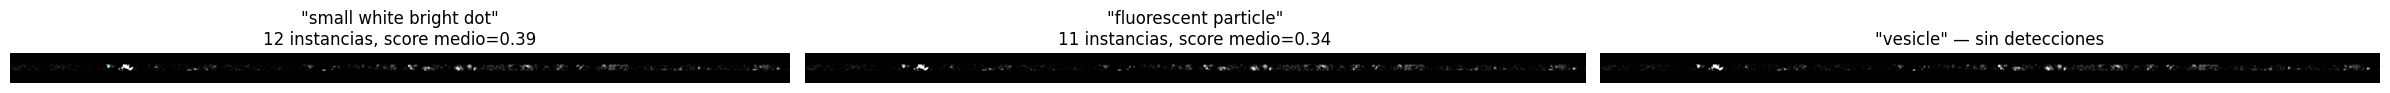

In [9]:
# Visualizacion en grid: una columna por query.
fig, axes = plt.subplots(1, len(TEXT_QUERIES), figsize=(8 * len(TEXT_QUERIES), 8))
if len(TEXT_QUERIES) == 1:
    axes = [axes]
for ax, q in zip(axes, TEXT_QUERIES):
    masks, scores = detecciones_c[q]
    if masks is None or len(masks) == 0:
        viz.mostrar_frame(frame_rgb, f'"{q}" — sin detecciones', ax=ax)
    else:
        viz.overlay_mascaras(frame_rgb, masks, ax=ax)
        s_mean = float(scores.mean()) if scores is not None and len(scores) else 0.0
        ax.set_title(f'"{q}"\n{len(masks)} instancias, score medio={s_mean:.2f}')
plt.tight_layout()
plt.show()

**Lectura de los resultados del Enfoque C:**

- **"small bright dot"** suele ser el más **permisivo** — encuentra muchas cosas pero también mezcla falsos positivos (agregados grandes que no son vesículas).
- **"fluorescent particle"** es más **conservador** — menos detecciones pero suele preferir blobs más grandes.
- **"vesicle"** suele devolver **cero** — SAM3 fue entrenado en imágenes naturales, no entiende el concepto biológico de "vesícula".

Esto es **informativo**: SAM3 sirve como detector general de "manchas brillantes" pero no como detector semántico de un concepto biológico específico.


---

## Comparación: B (Grounding DINO + SAM3) vs C (SAM3 con texto)

Acá está la pregunta clave: **¿el modelo unificado (C) le gana al pipeline en dos pasos (B)?**


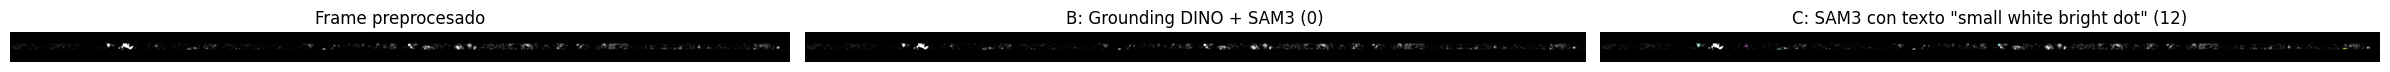

In [10]:
# Tomamos la mejor query del enfoque C para la comparacion (asumimos "small bright dot").
query_c = "small white bright dot"
masks_c, scores_c = detecciones_c[query_c]

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=axes[0])
viz.overlay_mascaras(frame_rgb, m_arr_b, ax=axes[1])
axes[1].set_title(f"B: Grounding DINO + SAM3 ({len(m_arr_b)})")
if masks_c is not None and len(masks_c) > 0:
    viz.overlay_mascaras(frame_rgb, masks_c, ax=axes[2])
axes[2].set_title(
    f'C: SAM3 con texto "{query_c}" ({0 if masks_c is None else len(masks_c)})'
)
plt.tight_layout()
plt.show()

**Observación esperada:** el Enfoque C (SAM3 unificado) suele detectar **más instancias** y con **máscaras más prolijas** que el Enfoque B (DINO + SAM3 separados). Esto pasa porque SAM3 fue entrenado _end-to-end_ para detección+segmentación, mientras que DINO + SAM3 son dos modelos que no comparten representaciones. La diferencia se nota especialmente en escenas con muchas instancias pequenias.


---

## Comparación con el notebook 02 (SAM2 vs SAM3)

Si corriste también [02_sam2_prototipo.ipynb](02_sam2_prototipo.ipynb), vale la pena comparar:

| Métrica                                       | SAM2             | SAM3                        |
| --------------------------------------------- | ---------------- | --------------------------- |
| Calidad de máscaras (Enfoque A, mismos blobs) | similar          | similar o ligeramente mejor |
| Cantidad de detecciones con texto             | N/A (no soporta) | varias decenas              |
| Velocidad                                     | ~1.5x más rápido | más lento (más parámetros)  |
| Tamanio del modelo                            | ~325 MB          | varios GB                   |

**Para este caso de uso (vesículas chicas en microscopía):**

- Ambos sufren con vesículas de 2–3 px porque están fuera de su distribución de entrenamiento.
- SAM3 abre la posibilidad de prompts de texto, lo cual es útil para prototipar sin etiquetar datos.
- La diferencia real va a aparecer cuando se combine con un **detector específico fine-tuneado** (ej: YOLO11 entrenado en 100 vesículas a mano). En ese escenario, SAM2 y SAM3 dan resultados de calidad similar; la elección depende más de velocidad y tamanio.


---

## Enfoque D — SAM3-Video: tracking en todo el video

Hasta acá usamos SAM3 en modo **imagen** (un frame a la vez). El modo **video** es lo que realmente hace tracking: a partir de un prompt en un frame, **propaga las máscaras a todos los siguientes manteniendo el ID** de cada objeto.

Flujo:

```
video procesado (T, H, W, 3)  +  text="small bright dot"
         │
         ▼
Sam3VideoModel
         │
         ▼
Output por cada frame:
  - object_ids: [1, 2, 3, ...] (IDs persistentes entre frames)
  - obj_id_to_mask: {1: mascara_1, 2: mascara_2, ...}
```

Es decir: el ID `1` en el frame 0 es la **misma vesícula** que el ID `1` en el frame 20. Eso es tracking.

**Importante:** este modelo usa otro checkpoint pesado. Si tu RAM/VRAM ya está justa por tener `model_sam3` cargado, conviene liberarlo primero (`del model_sam3`).


In [11]:
# Cargamos el video y aplicamos el rango configurado en `frames.inicio/fin`.
# Despues procesamos segun el modo (`completo`, `rgb_crudo`, o `configurable`).
from axonal_tracking.ets_reader import leer_video

video_crudo_full = leer_video(info)
video_crudo = cfg.recortar_video(video_crudo_full, config)
print(
    f"Video crudo recortado: shape={video_crudo.shape} (rango {config['frames']['inicio']}:{config['frames']['fin']}),"
    f" {video_crudo.nbytes/1e6:.0f} MB"
)

# aplicar_modo_video devuelve tuple (video, bbox) si `recorte_roi.habilitado=True`
# y hay ROI; si no, devuelve solo el array. Manejamos ambos casos para que el
# resto del notebook funcione en cualquier configuracion.
_resultado = cfg.aplicar_modo_video(video_crudo, config)
if isinstance(_resultado, tuple):
    video_procesado, bbox_video = _resultado
    print(
        f"Video procesado (modo={MODO}, recortado al bbox del ROI):"
        f" shape={video_procesado.shape}, bbox={bbox_video}, {video_procesado.nbytes/1e6:.0f} MB"
    )
else:
    video_procesado = _resultado
    bbox_video = None
    print(
        f"Video procesado (modo={MODO}): shape={video_procesado.shape},"
        f" {video_procesado.nbytes/1e6:.0f} MB"
    )

Video crudo recortado: shape=(111, 2048, 2048) (rango 0:None), 931 MB
Video procesado (modo=configurable, recortado al bbox del ROI): shape=(111, 81, 2083, 3), bbox={'polilinea': array([[ 837.        , 1956.        ],
       [ 836.9233035 , 1955.00294551],
       [ 836.846607  , 1954.00589103],
       ...,
       [1058.03547782,    7.28602957],
       [1058.63547782,    6.48602957],
       [1059.        ,    6.        ]], shape=(2083, 2)), 'normales': array([[ 0.99705449, -0.0766965 ],
       [ 0.99705449, -0.0766965 ],
       [ 0.99705449, -0.0766965 ],
       ...,
       [ 0.8       ,  0.6       ],
       [ 0.8       ,  0.6       ],
       [ 0.8       ,  0.6       ]], shape=(2083, 2)), 'ancho_banda': 40, 'shape_original': (2048, 2048)}, 56 MB


In [12]:
# Liberamos memoria del modelo de imagen antes de cargar el de video.
# (Comentalo si tenes RAM/VRAM de sobra y queres seguir usando model_sam3.)
import gc

try:
    del model_sam3, processor_sam3
except NameError:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

from transformers import Sam3VideoProcessor, Sam3VideoModel

# IMPORTANTE: cargamos los pesos en bfloat16 desde el principio. La session de
# inferencia castea las activaciones a `dtype=torch.bfloat16` (ver siguiente
# celda), asi que si dejaramos los pesos en float32 explotaria un Conv2d con
# "Input type (BFloat16) and bias type (Float) should be the same".
print("Cargando SAM3-Video en bfloat16...")
processor_video = Sam3VideoProcessor.from_pretrained(MODEL_ID)
model_video = (
    Sam3VideoModel.from_pretrained(MODEL_ID, dtype=torch.bfloat16).to(device).eval()
)
print(
    f"OK — SAM3-Video cargado en {device} (dtype={next(model_video.parameters()).dtype})."
)

Cargando SAM3-Video en bfloat16...


Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

OK — SAM3-Video cargado en mps (dtype=torch.bfloat16).


In [13]:
# Convertimos el video numpy (T, H, W, C) uint8 a tensor de PyTorch en formato
# (T, C, H, W). `torch.from_numpy` comparte memoria con el array original y
# `.permute` devuelve una vista — todo zero-copy, no duplica los ~56 MB del video.
video_tensor = torch.from_numpy(video_procesado).permute(0, 3, 1, 2)
print(
    f"Video tensor: {tuple(video_tensor.shape)} {video_tensor.dtype}"
    f" (T, C, H, W), contiguo={video_tensor.is_contiguous()}"
)

# Inicializar la sesion de inferencia con el video completo.
session = processor_video.init_video_session(
    video=video_tensor,
    inference_device=device,
    dtype=torch.bfloat16,
)
print(f"Sesion inicializada con {session.num_frames} frames.")

# Agregamos el prompt de texto. SAM3-Video va a detectar+trackear todas las
# instancias del concepto a lo largo del video.
TEXTO_TRACKING = "small bright dot"
processor_video.add_text_prompt(session, text=TEXTO_TRACKING)
print(f'Prompt agregado: "{TEXTO_TRACKING}"')

Video tensor: (111, 3, 81, 2083) torch.uint8 (T, C, H, W), contiguo=False
Sesion inicializada con 111 frames.
Prompt agregado: "small bright dot"


In [14]:
# Propagamos: el modelo recorre todos los frames y devuelve las mascaras
# de los objetos rastreados con sus IDs persistentes.
# Esto tarda unos minutos en MPS/CPU.

outputs_por_frame = {}  # frame_idx -> output
object_ids_vistos = set()

for out in model_video.propagate_in_video_iterator(session, show_progress_bar=True):
    outputs_por_frame[out.frame_idx] = out
    if out.object_ids:
        object_ids_vistos.update(out.object_ids)

print(f"\nFrames procesados: {len(outputs_por_frame)}")
print(f"Objetos unicos rastreados: {len(object_ids_vistos)}")
print(
    f'IDs: {sorted(object_ids_vistos)[:20]}{"..." if len(object_ids_vistos) > 20 else ""}'
)

propagate in video:   0%|          | 0/111 [00:00<?, ?it/s]

[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.



Frames procesados: 111
Objetos unicos rastreados: 1
IDs: [0]


### Reproductor de video del tracking

Un reproductor HTML5 con play/pause/scrub para ver el tracking en movimiento.

- Click en **▶** para reproducir.
- La barra de progreso te permite ir a cualquier frame.
- Cada vesícula tiene un **color fijo basado en su ID** — la misma vesícula tiene el mismo color en todos los frames donde aparece.

Si una vesícula se está moviendo, vas a ver la mancha del color desplazándose. Si está estática, el color queda quieto en el mismo lugar.

> **Nota:** la celda pre-renderiza los 86 frames con las máscaras quemadas adentro para que la reproducción sea fluida. Eso tarda algunos segundos al ejecutar la celda.


In [15]:
from matplotlib import animation
from IPython.display import HTML

# Color fijo por ID — la misma vesicula tiene siempre el mismo color
_rng = np.random.default_rng(42)
_colores_id = {
    oid: (_rng.random(3) * 255).astype(np.uint8) for oid in sorted(object_ids_vistos)
}


def _mascara_a_tamano(m, H, W):
    """Convierte tensor/array de mascara cruda de SAM3 a bool (H, W).

    Castea a float32 antes de .numpy() porque numpy no soporta bfloat16
    (que es el dtype con el que carga SAM3-Video en esta sesion).
    """
    if hasattr(m, "cpu"):
        arr = m.detach().to("cpu", dtype=torch.float32).numpy()
    else:
        arr = np.asarray(m)
    while arr.ndim > 2:
        arr = arr[0]  # quitar dims extras (batch, canal)
    if arr.shape != (H, W):
        # Resize con NEAREST para preservar bordes binarios
        arr = np.array(
            Image.fromarray((arr > 0).astype(np.uint8) * 255).resize(
                (W, H), Image.NEAREST
            )
        )
    return arr > 0


def renderizar_frame(frame_idx, alpha=0.55):
    """Devuelve el frame RGB con las mascaras de SAM3 quemadas adentro."""
    frame = video_procesado[frame_idx].copy()
    H, W = frame.shape[:2]
    out = outputs_por_frame.get(int(frame_idx))
    if out is None or not out.object_ids:
        return frame
    for oid in out.object_ids:
        m = out.obj_id_to_mask.get(oid)
        if m is None:
            continue
        m_np = _mascara_a_tamano(m, H, W)
        if not m_np.any():
            continue
        color = _colores_id.get(oid, np.array([255, 255, 0], dtype=np.uint8))
        frame[m_np] = (
            frame[m_np].astype(np.float32) * (1 - alpha) + color * alpha
        ).astype(np.uint8)
    return frame


# Pre-renderizamos todos los frames con las mascaras (vital para que el player vaya fluido).
print(f"Pre-renderizando {len(video_procesado)} frames con mascaras...")
frames_player = np.stack([renderizar_frame(i) for i in range(len(video_procesado))])
print(f"OK: {frames_player.shape}, {frames_player.nbytes / 1e6:.0f} MB en memoria.")

# Armamos la animacion HTML5
fig_player, ax_player = plt.subplots(figsize=(11, 8))
ax_player.axis("off")
img_artist = ax_player.imshow(frames_player[0])
title_artist = ax_player.set_title(
    f'Frame 0 / {len(frames_player) - 1} — texto: "{TEXTO_TRACKING}"'
)


def _actualizar(i):
    img_artist.set_array(frames_player[i])
    title_artist.set_text(
        f'Frame {i} / {len(frames_player) - 1} — texto: "{TEXTO_TRACKING}"'
    )
    return [img_artist, title_artist]


anim = animation.FuncAnimation(
    fig_player,
    _actualizar,
    frames=len(frames_player),
    interval=150,  # ms entre frames (~6.7 fps)
    blit=True,
)
plt.close(fig_player)  # evitamos que matplotlib muestre la figura estatica
HTML(anim.to_jshtml())

Pre-renderizando 111 frames con mascaras...
OK: (111, 81, 2083, 3), 56 MB en memoria.


### Visualización: máscaras a lo largo del video

Tomamos 6 frames distribuidos en el video y mostramos las máscaras de SAM3-Video. **Cada color es un mismo objeto** (ID persistente). Si la misma vesícula aparece con el mismo color en distintos frames, el tracking funcionó.


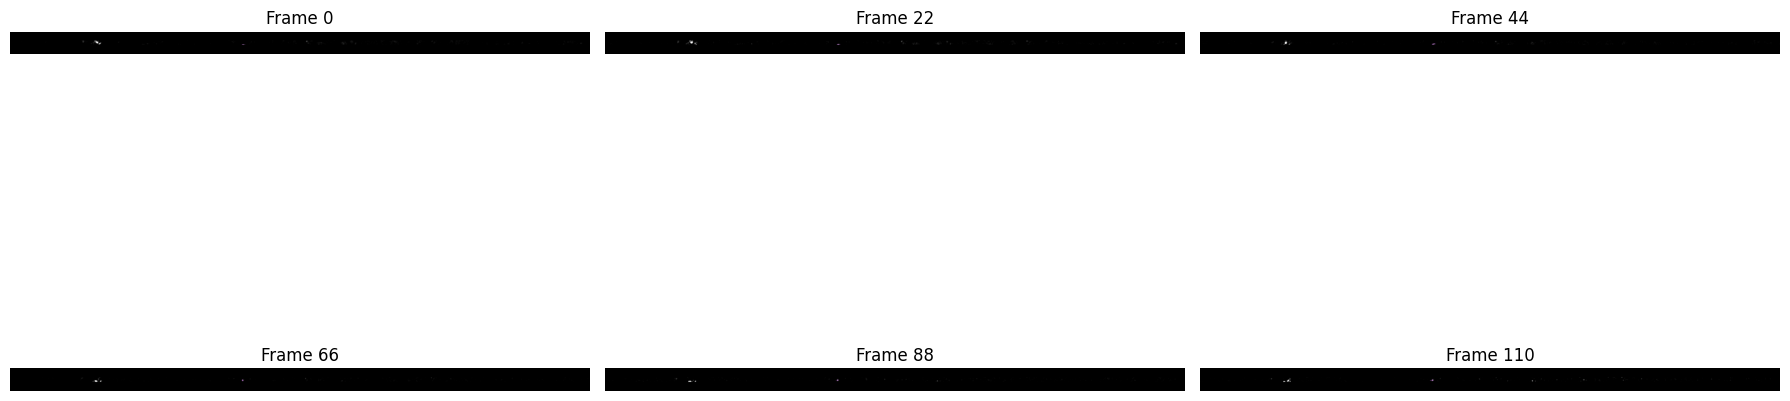

In [16]:
# Asignamos un color fijo por object_id (asi el mismo ID es siempre el mismo color).
rng_track = np.random.default_rng(42)
colores_id = {oid: rng_track.random(3) for oid in sorted(object_ids_vistos)}


def _mascara_a_tamano(m, H, W):
    """Convierte mascara cruda de SAM3 a bool (H, W), reescalando si hace falta.

    Castea a float32 antes de .numpy() porque numpy no soporta bfloat16.
    """
    if hasattr(m, "cpu"):
        arr = m.detach().to("cpu", dtype=torch.float32).numpy()
    else:
        arr = np.asarray(m)
    while arr.ndim > 2:
        arr = arr[0]
    if arr.shape != (H, W):
        arr = np.array(
            Image.fromarray((arr > 0).astype(np.uint8) * 255).resize(
                (W, H), Image.NEAREST
            )
        )
    return arr > 0


def overlay_tracking(frame_rgb_t, out, ax, alpha=0.6):
    H, W = frame_rgb_t.shape[:2]
    ax.imshow(frame_rgb_t)
    if out is None or not out.object_ids:
        return
    for oid in out.object_ids:
        m = out.obj_id_to_mask.get(oid)
        if m is None:
            continue
        m_np = _mascara_a_tamano(m, H, W)
        if not m_np.any():
            continue
        color = colores_id.get(oid, rng_track.random(3))
        overlay = np.zeros((H, W, 4))
        overlay[m_np] = [*color, alpha]
        ax.imshow(overlay)


# Elegimos 6 frames distribuidos
n_frames = len(video_procesado)
idxs_muestra = np.linspace(0, n_frames - 1, 6).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, fidx in zip(axes.flatten(), idxs_muestra):
    overlay_tracking(video_procesado[fidx], outputs_por_frame.get(int(fidx)), ax)
    ax.set_title(f"Frame {fidx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Trayectorias: posición de cada vesícula a lo largo del tiempo

Para cada objeto trackeado, calculamos el centroide de su máscara en cada frame y trazamos su recorrido. Esto es lo que finalmente se usa para calcular **velocidades** (µm/s) — el objetivo del proyecto.


In [17]:
# Para cada object_id, calculamos centroide (x, y) por frame.
H_VIDEO, W_VIDEO = video_procesado.shape[1], video_procesado.shape[2]
trayectorias = {oid: [] for oid in object_ids_vistos}  # oid -> [(t, x, y), ...]

for fidx, out in outputs_por_frame.items():
    if not out.object_ids:
        continue
    for oid in out.object_ids:
        m = out.obj_id_to_mask.get(oid)
        if m is None:
            continue
        m_np = _mascara_a_tamano(m, H_VIDEO, W_VIDEO)
        if not m_np.any():
            continue
        ys, xs = np.where(m_np)
        cx, cy = xs.mean(), ys.mean()
        trayectorias[oid].append((fidx, cx, cy))

# Ordenar por t y filtrar trayectorias muy cortas (< 5 frames).
trayectorias = {
    oid: sorted(tr, key=lambda x: x[0])
    for oid, tr in trayectorias.items()
    if len(tr) >= 5
}
print(
    f"Trayectorias validas (>= 5 frames): {len(trayectorias)} de {len(object_ids_vistos)} objetos."
)

Trayectorias validas (>= 5 frames): 1 de 1 objetos.


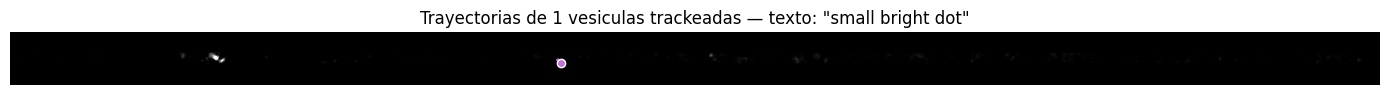

In [18]:
# Visualizamos las trayectorias sobre el frame 0 procesado.
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(video_procesado[0])

for oid, tr in trayectorias.items():
    ts, xs, ys = zip(*tr)
    color = colores_id.get(oid, (1, 1, 0))
    ax.plot(xs, ys, "-", color=color, linewidth=1.5, alpha=0.8)
    ax.plot(xs[0], ys[0], "o", color=color, mec="white", ms=6)  # marcador inicial

ax.set_title(
    f'Trayectorias de {len(trayectorias)} vesiculas trackeadas — texto: "{TEXTO_TRACKING}"'
)
ax.axis("off")
plt.tight_layout()
plt.show()

---

## Enfoque E — Multi-prompt ensemble

Las vesículas se mueven rápido respecto al tiempo de exposición (160–200 ms), así que en muchos frames aparecen como **estelas** en vez de puntos. El prompt `"small bright dot"` que veníamos usando captura bien las vesículas lentas pero **se pierde las rápidas** porque para SAM3 una estela no es un "dot".

**Solución:** correr SAM3-Video varias veces con prompts complementarios y combinar los tracks.

Cada query captura algo distinto:

| Query                         | Captura mejor                              |
| ----------------------------- | ------------------------------------------ |
| `"small bright dot"`          | Vesículas lentas / quietas                 |
| `"bright fluorescent streak"` | Vesículas en movimiento rápido (estelas)   |
| `"bright fluorescent spot"`   | Intermedio — manchas brillantes en general |

Resultado: más recall (menos vesículas perdidas) a costo de más cómputo (~3× el tiempo de un solo run).

**Nota:** correr este enfoque tarda varios minutos en MPS — son 3 propagaciones del video completo.


In [19]:
import gc

QUERIES_ENSEMBLE = [
    "small bright dot",
    "bright fluorescent streak",
    "bright fluorescent spot",
]

# Un color caracteristico por query — asi vemos visualmente que prompt aporta que.
colores_query = {
    "small bright dot": (1.0, 0.2, 0.2),  # rojo
    "bright fluorescent streak": (0.2, 1.0, 0.4),  # verde
    "bright fluorescent spot": (0.3, 0.5, 1.0),  # azul
}


def _liberar_mps():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()


def correr_sam3_video(texto, video):
    """Init session + add text + propagar. Devuelve {frame_idx: output}.

    `video` es un tensor de PyTorch (T, C, H, W) — el processor lo acepta
    directamente, evitamos la conversion a PIL.

    Usamos bfloat16 para matchear los pesos del modelo (ver celda de carga).

    Libera memoria de la session al final — sin esto, corridas sucesivas
    acumulan caches de frames en MPS y la 2da/3ra query se vuelven lentísimas.
    """
    session = processor_video.init_video_session(
        video=video,
        inference_device=device,
        dtype=torch.bfloat16,
    )
    processor_video.add_text_prompt(session, text=texto)
    outputs = {}
    for out in model_video.propagate_in_video_iterator(session, show_progress_bar=True):
        outputs[out.frame_idx] = out
    del session
    _liberar_mps()
    return outputs


# Liberamos la session de Enfoque D si quedo viva (no la necesitamos mas).
try:
    del session
except NameError:
    pass
_liberar_mps()

# Corremos las 3 queries (esto tarda — varios minutos por query).
outputs_ensemble = {}
for i, q in enumerate(QUERIES_ENSEMBLE, 1):
    print(f'[{i}/{len(QUERIES_ENSEMBLE)}] Corriendo SAM3-Video con: "{q}"...')
    outputs_ensemble[q] = correr_sam3_video(q, video_tensor)
    n_objs = len(
        {
            oid
            for out in outputs_ensemble[q].values()
            if out.object_ids
            for oid in out.object_ids
        }
    )
    print(f"    -> {n_objs} objetos rastreados")

print("\nResumen por query:")
for q, outs in outputs_ensemble.items():
    n_objs = len(
        {oid for out in outs.values() if out.object_ids for oid in out.object_ids}
    )
    n_frames_con_det = sum(1 for out in outs.values() if out.object_ids)
    print(
        f'  "{q:30s}" : {n_objs:3d} objetos, en {n_frames_con_det}/{len(outs)} frames'
    )

[1/3] Corriendo SAM3-Video con: "small bright dot"...


propagate in video:   0%|          | 0/111 [00:00<?, ?it/s]

    -> 1 objetos rastreados
[2/3] Corriendo SAM3-Video con: "bright fluorescent streak"...


propagate in video:   0%|          | 0/111 [00:00<?, ?it/s]

    -> 1 objetos rastreados
[3/3] Corriendo SAM3-Video con: "bright fluorescent spot"...


propagate in video:   0%|          | 0/111 [00:00<?, ?it/s]

    -> 4 objetos rastreados

Resumen por query:
  "small bright dot              " :   1 objetos, en 111/111 frames
  "bright fluorescent streak     " :   1 objetos, en 14/111 frames
  "bright fluorescent spot       " :   4 objetos, en 111/111 frames


### Reproductor del ensemble

Reproductor HTML5 con todas las máscaras del ensemble superpuestas. **El color indica qué query detectó cada objeto:**

- 🔴 Rojo — `"small bright dot"`
- 🟢 Verde — `"bright fluorescent streak"`
- 🔵 Azul — `"bright fluorescent spot"`

Si una vesícula aparece de un solo color, sólo ese prompt la detecta. Si aparece de varios colores superpuestos (matizada), varios prompts la encuentran — eso es buena señal de que la detección es robusta.


In [20]:
from matplotlib import animation
from IPython.display import HTML


def renderizar_ensemble(frame_idx, alpha=0.5):
    """Frame RGB con mascaras de todas las queries, coloreadas por query."""
    frame = video_procesado[frame_idx].copy()
    H, W = frame.shape[:2]
    for q, outs in outputs_ensemble.items():
        out = outs.get(int(frame_idx))
        if out is None or not out.object_ids:
            continue
        color = (np.array(colores_query[q]) * 255).astype(np.uint8)
        for oid in out.object_ids:
            m = out.obj_id_to_mask.get(oid)
            if m is None:
                continue
            m_np = _mascara_a_tamano(m, H, W)
            if not m_np.any():
                continue
            frame[m_np] = (
                frame[m_np].astype(np.float32) * (1 - alpha) + color * alpha
            ).astype(np.uint8)
    return frame


print("Pre-renderizando ensemble...")
frames_ensemble = np.stack(
    [renderizar_ensemble(i) for i in range(len(video_procesado))]
)
print(f"OK: {frames_ensemble.shape}")

fig_e, ax_e = plt.subplots(figsize=(11, 8))
ax_e.axis("off")
img_e = ax_e.imshow(frames_ensemble[0])
title_e = ax_e.set_title("Frame 0 — ensemble (rojo=dot, verde=streak, azul=spot)")


def _upd_e(i):
    img_e.set_array(frames_ensemble[i])
    title_e.set_text(
        f"Frame {i} / {len(frames_ensemble) - 1} — ensemble (rojo=dot, verde=streak, azul=spot)"
    )
    return [img_e, title_e]


anim_e = animation.FuncAnimation(
    fig_e,
    _upd_e,
    frames=len(frames_ensemble),
    interval=150,
    blit=True,
)
plt.close(fig_e)
HTML(anim_e.to_jshtml())

Pre-renderizando ensemble...
OK: (111, 81, 2083, 3)


### Cómo interpretar el ensemble

Mirá el reproductor frame por frame:

- **Zonas predominantemente rojas** → vesículas que `"small bright dot"` ya estaba detectando. No hay novedad.
- **Zonas predominantemente verdes** → las **vesículas en movimiento rápido** que estábamos perdiendo. Si ves muchas verdes que NO eran rojas en el reproductor anterior, el ensemble está pagando.
- **Zonas violetas/amarillas (mezcla de colores)** → vesículas que múltiples prompts coinciden en detectar. Esas son las detecciones más confiables — útil para construir un "set de oro" filtrando sólo lo que dos o más queries acuerden.
- **Si una región específica del axón sólo se enciende verde en frames donde se ve una estela** → confirmación de que el prompt `"streak"` está capturando exactamente lo que esperabamos.

**Si querés probar más queries:** agregá strings a `QUERIES_ENSEMBLE` y un color en `colores_query`. Cada query nueva agrega ~1 propagación de video completo al tiempo de cómputo.


### Cómo leer las trayectorias

- **Cada línea coloreada** es una vesícula distinta (ID persistente).
- **Punto blanco con borde** = posición en el primer frame donde se detectó.
- **Líneas largas a lo largo del axón** = transporte activo (lo que buscamos).
- **Puntos quietos / clusters pequeños** = objetos estáticos que el modelo segmentó pero no se movieron.

Si querés convertir esto a velocidades en µm/s:

```python
from axonal_tracking.parametros import PIXEL_SIZE_UM, segundos_por_frame
dt = segundos_por_frame(VIDEO)  # s/frame de la sesion
for oid, tr in trayectorias.items():
    ts, xs, ys = zip(*tr)
    dx = np.diff(xs); dy = np.diff(ys); dts = np.diff(ts) * dt
    v_um_s = (np.sqrt(dx**2 + dy**2) / dts) * PIXEL_SIZE_UM
    print(f'Vesicula {oid}: velocidad media {v_um_s.mean():.2f} um/s')
```

Para `Ex/Movie_674.vsi` el framerate (`dt`) no está documentado — habría que pedirlo al lab (ver [docs/dataset-findings.md](../docs/dataset-findings.md) §E.18a).


---

## Próximos pasos

1. **Tracking en video con SAM3-video**: extender el Enfoque C a un video completo. SAM3 tiene un modo video que propaga las máscaras del frame 0 a los siguientes manteniendo identidad.
2. **Tunear los queries de texto**: probar más frases (`"axonal transport granule"`, `"bright punctum"`, etc.) para ver cuál mapea mejor al concepto de vesícula.
3. **Cuantificación**: medir velocidades en µm/s usando [parametros.py](../src/axonal_tracking/parametros.py) y comparar contra el ground truth manual.
4. **Aplicar la máscara del ROI a posteriori**: filtrar las detecciones que cayeron fuera del axón. Es una mejora ortogonal a cualquier enfoque (A, B, C).
